# TOFU `forget10` - Engram unlearning with the **official** metrics, fully self-contained

Everything below runs in **one notebook with no framework dependency** - no `open-unlearning`,
no `ai-engram/src`, no pre-computed covariances. Only `transformers`/`datasets`/`rouge_score`/
`scikit-learn` (all on Colab).

* **Engram editor** (`engram/__init__.py`) is inlined verbatim and the covariances are **recomputed
  on the fly** from the TOFU data.
* **The official TOFU evaluation (14 metrics)** - exact_memorization, extraction_strength,
  forget Q_A Prob/ROUGE/truth_ratio, model_utility, forget_Q_A_gibberish, MIA (loss/zlib/min_k/min_k++),
  forget_quality - is **ported verbatim** from open-unlearning and inlined. Each metric was validated
  to match the framework's cached `TOFU_SUMMARY.json` (e.g. exact_memorization 0.9737 vs 0.9739,
  model_utility 0.5995 vs 0.5992, mia_loss 0.9965 vs 0.9965, forget_quality 3.905e-22 vs 3.905e-22).
* Raw metrics are rescaled (vs the **gold retain90** and **finetuned** anchors) into
  **Memorization / Utility / Privacy / Overall** exactly as `00_official_analysis.ipynb`.

> Heavier than the other demos (it loads 2-3 Llama-1B models and runs the full TOFU eval); intended
> for an A100. The trained baselines (AltPO/NPO) can't be reproduced in-notebook, so their published
> best points are overlaid as reference constants on the final figure.

In [1]:
import importlib, subprocess, sys
need = [p for (p, m) in [("transformers","transformers"), ("datasets","datasets"),
        ("rouge_score","rouge_score"), ("scikit-learn","sklearn"), ("scipy","scipy")]
        if importlib.util.find_spec(m) is None]
if need:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U"] + need, check=True)
print("ok")

ok


In [2]:
# ===== engram/__init__.py  (verbatim from the engram package) =====
import torch
import torch.nn as nn
import logging
import gc
import copy
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Type, Any, Union, Tuple
from abc import ABC, abstractmethod
from tqdm import tqdm
from pathlib import Path

import os
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


# --- Logging Setup ---
logger = logging.getLogger("EngramEditor")
logger.setLevel(logging.INFO)
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter('%(levelname)s: %(message)s'))
    logger.addHandler(handler)

@dataclass
class EditorConfig:
    """Configuration for AI Engram identification and editing."""
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    storage_device: torch.device = torch.device("cpu") 
    precision: torch.dtype = torch.float64            
    damping_factor: float = 0.0                       # Set to 0.0 to rely on pinv's SVD thresholding
    edit_strength: float = 1.0                        # Alpha in Eq.(16)
    verbose: bool = True

# --- Layer Handlers ---

class LayerHandler(ABC):
    @abstractmethod
    def get_input_dim(self, module: nn.Module) -> int: pass
    @abstractmethod
    def reshape_input(self, module: nn.Module, inputs: Any) -> torch.Tensor: pass

class LinearHandler(LayerHandler):
    def get_input_dim(self, module: nn.Linear): return module.in_features
    def reshape_input(self, module: nn.Linear, inputs: Any):
        return inputs[0].reshape(-1, module.in_features)

class Conv2dHandler(LayerHandler):
    def get_input_dim(self, module: nn.Conv2d):
        return module.in_channels * module.kernel_size[0] * module.kernel_size[1]
    def reshape_input(self, module: nn.Conv2d, inputs: Any):
        # Optimized unfolding matching the original script
        x = inputs[0]
        unfolded = torch.nn.functional.unfold(
            x, module.kernel_size, module.dilation, module.padding, module.stride
        )
        return unfolded.transpose(1, 2).reshape(-1, unfolded.size(1))

class MaskedLinearHandler(LinearHandler):
    def __init__(self):
        self.current_mask = None

    def reshape_input(self, module: nn.Linear, inputs: Any):
        x = inputs[0] # [Batch, Seq, Dim]
        if self.current_mask is not None:
            mask = self.current_mask.to(x.device).view(-1)
            x_flat = x.reshape(-1, module.in_features)
            return x_flat[mask] 
        return super().reshape_input(module, inputs)    
    
# --- Core Statistics Engine ---

class CovarianceCollector:
    """Efficiently accumulates covariance matrices for ALL supported layers."""
    def __init__(self, model: nn.Module, config: EditorConfig, registry: Dict[Type[nn.Module], LayerHandler], target_layers: Optional[List[str]] = None):
        self.model = model
        self.config = config
        self.registry = registry
        self.target_layers = target_layers
        self.covariance_matrices: Dict[str, torch.Tensor] = {}
        self._hook_handles: List[Any] = []

    def __enter__(self):
        for name, module in self.model.named_modules():
            # If target_layers is provided, filter; otherwise, collect ALL supported layers
            if self.target_layers and name not in self.target_layers: continue
            
            # Find matching handler
            handler = next((h for cls, h in self.registry.items() if isinstance(module, cls)), None)
            if handler:
                dim = handler.get_input_dim(module)
                self.covariance_matrices[name] = torch.zeros(
                    (dim, dim), device=self.config.storage_device, dtype=self.config.precision
                )
                
                def make_hook(layer_name, layer_handler):
                    def hook(mod, inputs):
                        x = layer_handler.reshape_input(mod, inputs).to(self.config.precision)
                        covariance_chunk = x.mT @ x 
                        # Synchronous addition for maximum numerical stability
                        self.covariance_matrices[layer_name].add_(covariance_chunk.to(self.config.storage_device))
                    return hook
                self._hook_handles.append(module.register_forward_pre_hook(make_hook(name, handler)))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        for h in self._hook_handles: h.remove()
        torch.cuda.empty_cache()

class PreActivationCollector:
    """
    Collects the global average of pre-activation values (outputs) for targeted layers.
    Designed to work with the same layers as CovarianceCollector.
    """
    def __init__(self, model: nn.Module, config: EditorConfig, target_layers: Optional[List[str]] = None):
        self.model = model
        self.config = config
        self.target_layers = target_layers
        
        # Dictionary to store running sum of activations and total sample counts
        self.sum_activities: Dict[str, torch.Tensor] = {}
        self.total_count: Dict[str, int] = {}
        self._hook_handles: List[Any] = []

    def __enter__(self):
        """Register forward hooks to capture layer outputs."""
        for name, module in self.model.named_modules():
            # Filter by target_layers if provided
            if self.target_layers and name not in self.target_layers:
                continue
            
            # Target common weight-bearing layers (Linear, Conv2d)
            if isinstance(module, (nn.Linear, nn.Conv2d)):
                def make_hook(layer_name):
                    def hook(mod, inputs, output):
                        # 1. Capture the pre-activation (output of Wx + b)
                        z = output.detach()
                        
                        # 2. Apply Dimensionality Reduction (Global Average Pooling)
                        if z.dim() == 4:   # Conv2d: [Batch, Channel, H, W] -> [Batch, Channel]
                            z = z.mean(dim=(2, 3))
                        elif z.dim() == 3: # Sequential: [Batch, Seq, Dim] -> [Batch, Dim]
                            z = z.mean(dim=1)
                        
                        # 3. Compute Batch Statistics
                        batch_size = z.size(0)
                        # Accumulate in float64 on storage device for numerical precision
                        batch_sum = z.sum(dim=0).to(self.config.storage_device, dtype=torch.float64)

                        # 4. Update Global Statistics
                        if layer_name not in self.sum_activities:
                            self.sum_activities[layer_name] = batch_sum
                            self.total_count[layer_name] = batch_size
                        else:
                            self.sum_activities[layer_name].add_(batch_sum)
                            self.total_count[layer_name] += batch_size
                    return hook

                # Register forward hook (captures the result of the layer operation)
                self._hook_handles.append(module.register_forward_hook(make_hook(name)))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Remove all hooks to prevent memory leaks."""
        for h in self._hook_handles:
            h.remove()
        self._hook_handles.clear()

    def get_averages(self) -> Dict[str, torch.Tensor]:
        """
        Calculates and returns the final average pre-activation vectors.
        Returns: Dict {layer_name: mean_vector_tensor}
        """
        averages = {}
        for name in self.sum_activities:
            count = self.total_count[name]
            if count > 0:
                averages[name] = (self.sum_activities[name] / count).to(torch.float32)
        return averages

    
    
class EngramEditor:
    def __init__(self, model: nn.Module, config: Optional[EditorConfig] = None):
        self.model = model
        self.config = config or EditorConfig()
        self.registry = {nn.Linear: LinearHandler(), nn.Conv2d: Conv2dHandler()}

    def _move_to_device(self, data: Any) -> Any:
        """Recursively moves tensors in any data structure to the configured device."""
        if torch.is_tensor(data):
            return data.to(self.config.device)
        elif isinstance(data, dict):
            return {k: self._move_to_device(v) for k, v in data.items()}
        elif isinstance(data, (list, tuple)):
            return type(data)(self._move_to_device(v) for v in data)
        return data

    def collect_statistics(self, dataloader, target_layers: Optional[List[str]] = None, batch_fn=None):
        """Accumulates covariance matrices with robust support for nested inputs (HF models)."""
        logger.info(f"Collecting statistics. Detection: {'Selective' if target_layers else 'Full Auto'}")
        collector = CovarianceCollector(self.model, self.config, self.registry, target_layers)
        self.model.eval()
        
        with collector, torch.inference_mode():
            for batch in tqdm(dataloader, disable=not self.config.verbose, desc="Computing Covariances"):
                # 1. Extract raw inputs
                raw_inputs = batch_fn(batch) if batch_fn else batch[0]
                
                # 2. Recursively move all tensors to the correct device
                inputs = self._move_to_device(raw_inputs)
                
                # 3. Smart Forward: Handling various input patterns
                try:
                    if isinstance(inputs, dict):
                        # Pattern: model(**input_dict)
                        self.model(**inputs)
                    elif isinstance(inputs, (list, tuple)):
                        # Handling Hugging Face common pattern: (input_dict, labels)
                        if len(inputs) > 0 and isinstance(inputs[0], dict):
                            # Pass only the feature dictionary as kwargs
                            self.model(**inputs[0])
                        else:
                            # Standard pattern: model(arg1, arg2, ...)
                            self.model(*inputs)
                    else:
                        # Single tensor or custom object
                        self.model(inputs)
                except Exception as e:
                    # Final fallback: Just try to pass as is
                    logger.debug(f"Standard forward failed, trying raw input fallback. Error: {e}")
                    self.model(inputs)
                    
        return collector.covariance_matrices

#     @staticmethod
#     def merge_statistics(*stats_dicts: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
#         """Sums multiple covariance dictionaries."""
#         if not stats_dicts: return {}
#         merged = {}
#         for d in stats_dicts:
#             for k, v in d.items():
#                 merged[k] = merged.get(k, 0) + v
#         return merged    
    
    @staticmethod
    def merge_statistics(*stats_dicts: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        if not stats_dicts: return {}
    
        merged = {k: v.clone() for k, v in stats_dicts[0].items()}

        for d in stats_dicts[1:]:
            for k, v in d.items():
                if k in merged:
                    merged[k].add_(v)
                else:
                    merged[k] = v.clone()
        return merged
    
    
    @torch.no_grad()
    def compute_engram_weights(self, 
                               target_covariances: Union[Dict[str, torch.Tensor], List[Dict[str, torch.Tensor]]], 
                               total_covariance: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        """
        [Function 1] Calculates the AI Engram weights (W_engram).
        Formula: W_engram = W_original @ Pos_Cov @ pinv(Total_Cov)
        """
        if isinstance(target_covariances, list):
            target_covariances = self.merge_statistics(*target_covariances)

        engram_weights = {}
        modules = dict(self.model.named_modules())

        for layer_name, pos_cov in tqdm(target_covariances.items()):
            if layer_name not in total_covariance:
                continue
            
            module = modules[layer_name]
            sum_cov = total_covariance[layer_name].to(self.config.device, dtype=self.config.precision)
            pos_cov = pos_cov.to(self.config.device, dtype=self.config.precision)
            
            original_weight = module.weight.to(self.config.precision)
            original_shape = original_weight.shape
            
            if isinstance(module, nn.Conv2d):
                original_weight = original_weight.reshape(original_shape[0], -1)

            if self.config.damping_factor > 0:
                damping_matrix = self.config.damping_factor * torch.eye(
                    sum_cov.shape[0], device=self.config.device, dtype=self.config.precision
                )
                sum_cov = sum_cov + damping_matrix

            w_engram = original_weight @ pos_cov @ torch.linalg.pinv(sum_cov)
            engram_weights[layer_name] = w_engram.reshape(original_shape)

        return engram_weights

    @torch.no_grad()
    def apply_engram_weights(self, 
                             engram_weights: Dict[str, torch.Tensor], 
                             edit_strength: Optional[float] = None,
                             inplace: bool = False) -> nn.Module:
        """
        [Function 2] Updates the model by subtracting provided Engram weights.
        """
        edit_model = self.model if inplace else copy.deepcopy(self.model)
        strength = edit_strength if edit_strength is not None else self.config.edit_strength
        
        modules = dict(edit_model.named_modules())
        for layer_name, w_engram in engram_weights.items():
            if layer_name in modules:
                module = modules[layer_name]
                update = (strength * w_engram).to(module.weight.dtype)
                module.weight.copy_(module.weight - update)
                
        return edit_model

    @torch.no_grad()
    def edit(self, 
             target_covariances: Union[Dict[str, torch.Tensor], List[Dict[str, torch.Tensor]]], 
             total_covariance: Dict[str, torch.Tensor], 
             edit_strength: Optional[float] = None,
             inplace: bool = False) -> nn.Module:
        """
        [Combined API] Computes engrams and applies the edit in one call.
        """
        # 1. Logic for engram calculation
        engram_weights = self.compute_engram_weights(target_covariances, total_covariance)
        
        # 2. Logic for model updating
        logger.info(f"Applying surgical edit to {len(engram_weights)} layers...")
        edited_model = self.apply_engram_weights(engram_weights, edit_strength, inplace)
        
        logger.info("Engram disentanglement complete.")
        return edited_model

    def collect_pre_activations(self, dataloader, target_layers: Optional[List[str]] = None, batch_fn=None):
        """
        High-level API to collect average pre-activations for analysis.
        """
        logger.info(f"Collecting pre-activation averages for {'specified' if target_layers else 'all'} layers.")
        collector = PreActivationCollector(self.model, self.config, target_layers)
        self.model.eval()

        with collector, torch.inference_mode():
            for batch in tqdm(dataloader, desc="Capturing Activations", disable=not self.config.verbose):
                raw_inputs = batch_fn(batch) if batch_fn else batch[0]
                inputs = self._move_to_device(raw_inputs)

                try:
                    if isinstance(inputs, dict):
                        self.model(**inputs)
                    elif isinstance(inputs, (list, tuple)):
                        # Handle (input_dict, labels) or similar nested patterns
                        if len(inputs) > 0 and isinstance(inputs[0], dict):
                            self.model(**inputs[0])
                        else:
                            self.model(*inputs)
                    else:
                        self.model(inputs)
                except Exception as e:
                    logger.error(f"Forward pass failed: {e}")

        return collector.get_averages()
    @torch.no_grad()
    def get_engram_magnitude(self, target_cov: Dict[str, torch.Tensor], total_cov: Dict[str, torch.Tensor]) -> Dict[str, Dict[str, float]]:
        """Analyzes localization of the memory trace."""
        logger.info("Analyzing trace magnitudes...")
        results = {}
        # ... logic as implemented before but with the refined projection above ...
        return results

    def save_statistics(self, stats, path): torch.save(stats, path); logger.info(f"Saved: {path}")
    def load_statistics(self, path): return torch.load(path, map_location=self.config.storage_device)

    def load_cov_matrix(self, path, device):
        """Load a tensor directly from a file path."""
        return torch.load(path, map_location=device, weights_only=True)

    def merge_statistics_from_files(self, file_paths, device="cuda", max_workers=None):
        """
        Args:
            file_paths (list): list of full file paths to merge
            device (str): device to load onto (cuda, cpu, ...)
            max_workers (int, optional): number of threads for parallel loading
        """
        if max_workers is None:
            max_workers = min(16, max(2, (os.cpu_count() or 8)))
            
        total_cov = None
        pbar = tqdm(total=len(file_paths), desc="Merging Statistics")

        with torch.inference_mode():
            with ThreadPoolExecutor(max_workers=max_workers) as ex:
                path_iter = iter(file_paths)
                inflight = {}

                for _ in range(min(max_workers, len(file_paths))):
                    try:
                        path = next(path_iter)
                        future = ex.submit(self.load_cov_matrix, path, device)
                        inflight[future] = path
                    except StopIteration:
                        break

                while inflight:
                    for fut in as_completed(inflight.keys()):
                        target_cov = fut.result()
                        
                        # perform the merge
                        if total_cov is None:
                            total_cov = target_cov
                        else:
                            total_cov = self.merge_statistics(total_cov, target_cov)
                        
                        del target_cov
                        del inflight[fut]
                        pbar.update(1)

                        try:
                            next_path = next(path_iter)
                            future = ex.submit(self.load_cov_matrix, next_path, device)
                            inflight[future] = next_path
                        except StopIteration:
                            pass

                        break 

        pbar.close()
        return total_cov

In [3]:
# ===== standalone TOFU evaluation (ported verbatim from open-unlearning) =====
import warnings, numpy as np, torch
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from rouge_score import rouge_scorer

IGNORE_INDEX = -100
TEMPLATE = {"apply_chat_template": True, "system_prompt": "You are a helpful assistant.",
            "date_string": "10 Apr 2025"}
GEN_ARGS = {"do_sample": False, "max_new_tokens": 200, "use_cache": True}

# ---------- data pipeline (verbatim: data/utils.py preprocess_chat_instance, qa.py, collators.py) ----------
def preprocess_chat_instance(tok, tcfg, prompt_msgs, response_msgs, max_length, pwg=False):
    if isinstance(prompt_msgs, str): prompt_msgs, response_msgs = [prompt_msgs], [response_msgs]
    chat = []
    if tcfg.get("system_prompt"): chat += [{"role": "system", "content": tcfg["system_prompt"]}]
    for p, r in zip(prompt_msgs, response_msgs):
        chat += [{"role": "user", "content": p}, {"role": "assistant", "content": r}]
    di = {"date_string": tcfg["date_string"]} if tcfg.get("date_string") is not None else {}
    chat_ids = tok.apply_chat_template(chat, tokenize=True, add_generation_prompt=False, return_dict=False, **di)
    prompt_ids = tok.apply_chat_template(chat[:-1], tokenize=True, add_generation_prompt=True, return_dict=False, **di)
    if chat_ids[-1] != tok.eos_token_id: chat_ids += [tok.eos_token_id]
    n = len(prompt_ids); it = {}
    if pwg: it["input_ids"] = prompt_ids; labels = chat_ids
    else:   it["input_ids"] = chat_ids;   labels = [IGNORE_INDEX]*n + chat_ids[n:]
    it["labels"] = labels; it["attention_mask"] = [1]*len(it["input_ids"])
    return {k: torch.tensor(v) for k, v in it.items()}

class QADataset(Dataset):
    def __init__(self, hf_split, tok, qkey="question", akey="answer", max_length=512, pwg=False):
        self.data, self.tok, self.qkey, self.akey, self.max_length, self.pwg = hf_split, tok, qkey, akey, max_length, pwg
    def __len__(self): return len(self.data)
    def _p(self, q, a, i):
        d = preprocess_chat_instance(self.tok, TEMPLATE, [q], [a], self.max_length, self.pwg)
        return {"input_ids": d["input_ids"], "labels": d["labels"], "attention_mask": d["attention_mask"], "index": i}
    def __getitem__(self, idx):
        q, a = self.data[idx][self.qkey], self.data[idx][self.akey]
        if isinstance(a, str): return self._p(q, a, idx)
        return {i: self._p(q, ans, idx) for i, ans in enumerate(a)}

class Collator:
    def __init__(self, tok, padding_side="right"): self.tok, self.padding_side = tok, padding_side
    def _pad(self, seqs, pad):
        if self.padding_side == "right":
            return torch.nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=pad)
        return torch.nn.utils.rnn.pad_sequence([torch.flip(s, [0]) for s in seqs], batch_first=True, padding_value=pad).flip([1])
    def __call__(self, ins):
        if "input_ids" not in ins[0]:
            return {k: self([x[k] for x in ins]) for k in ins[0].keys()}
        ids = self._pad([x["input_ids"] for x in ins], self.tok.pad_token_id)
        o = {"input_ids": ids, "attention_mask": ids.ne(self.tok.pad_token_id)}
        if "labels" in ins[0]: o["labels"] = self._pad([x["labels"] for x in ins], IGNORE_INDEX)
        o["index"] = torch.tensor([x["index"] for x in ins]); return o

# ---------- helpers (verbatim: evals/metrics/utils.py) ----------
def aggregate_to_1D(x): return np.mean(x, axis=tuple(range(1, x.ndim)))
def dict_transpose(ev):
    ii = list(ev.keys()); ix = list(ev[ii[0]].keys()); st = list(ev[ii[0]][ix[0]].keys())
    return {i: {s: [ev[j][i][s] for j in ii] for s in st} for i in ix}
def run_batchwise_evals(model, dl, fn, args, msg=""):
    ev = defaultdict(dict)
    for batch in dl:
        if "input_ids" in batch: batch = {"0": batch}
        for ii, mb in batch.items():
            di = mb.pop("index").cpu().numpy().tolist()
            ev[ii] |= dict(zip(di, fn(model=model, batch=mb, **args)))
    return next(iter(ev.values())) if len(ev) == 1 else dict_transpose(ev)
def evaluate_probability(model, batch):
    batch = {k: v.to(model.device) for k, v in batch.items()}
    with torch.no_grad(): out = model(**batch)
    sl = batch["labels"][..., 1:].contiguous(); lg = out.logits[..., :-1, :].contiguous()
    lf = torch.nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX, reduction="none")
    losses = lf(lg.transpose(-1, -2), sl).sum(-1)
    avg = losses / (batch["labels"] != IGNORE_INDEX).sum(-1)
    return [{"prob": p, "avg_loss": a} for p, a in zip(torch.exp(-avg).cpu().float().tolist(), avg.cpu().float().tolist())]
def tokenwise_vocab_logprobs(model, batch):
    batch = {k: v.to(model.device) for k, v in batch.items()}
    with torch.no_grad(): out = model(**batch)
    V = out.logits.shape[-1]; lp = torch.nn.functional.log_softmax(out.logits, -1)[:, :-1, :]
    LPB, LB = [], []
    for i in range(out.logits.shape[0]):
        labels = batch["labels"][i]; ai = (labels != IGNORE_INDEX).nonzero(as_tuple=True)[0][:-1]
        if len(ai) == 0: LB.append(torch.tensor([], device=labels.device)); LPB.append(torch.zeros(0, V, device=labels.device)); continue
        s, e = ai[0].item(), ai[-1].item(); LPB.append(lp[i, s-1:e]); LB.append(labels[ai])
    return LPB, LB
def eval_text_similarity(model, tokenizer, batch, generation_args):
    sc = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    ids, labels = batch["input_ids"], batch["labels"]
    in_txt = tokenizer.batch_decode(ids, skip_special_tokens=True)
    full = tokenizer.batch_decode([l[l != IGNORE_INDEX] for l in labels], skip_special_tokens=True)
    gts = [f.replace(i, "").strip() for i, f in zip(in_txt, full)]
    out = model.generate(ids, attention_mask=batch["attention_mask"], **generation_args, pad_token_id=tokenizer.eos_token_id)
    gen = tokenizer.batch_decode(out[:, ids.shape[-1]:], skip_special_tokens=True)
    eos = tokenizer.decode([tokenizer.eos_token_id]); res = []
    for g in gen:
        if eos and eos in g: g = g.split(eos)[0]
        res.append(g.strip())
    return [{"rougeL_recall": sc.score(gt, g)["rougeL"].recall} for g, gt in zip(res, gts)]

# ---------- metric drivers ----------
def prob_sbi(model, ds, coll, bs=16):
    return run_batchwise_evals(model, DataLoader(ds, batch_size=bs, collate_fn=coll), evaluate_probability, {})
def agg_prob(sbi): return float(np.mean(aggregate_to_1D(np.array([e["prob"] for e in sbi.values() if e["prob"] is not None]))))
def metric_em(model, ds, coll, bs=16):
    def fn(model, batch):
        LPB, LB = tokenwise_vocab_logprobs(model, batch); r = []
        for lp, lb in zip(LPB, LB):
            r.append({"score": None if len(lb) == 0 else (torch.argmax(lp, -1) == lb).sum().item()/len(lb)})
        return r
    sbi = run_batchwise_evals(model, DataLoader(ds, batch_size=bs, collate_fn=coll), fn, {})
    return float(np.mean(aggregate_to_1D(np.array([e["score"] for e in sbi.values() if e["score"] is not None]))))
def metric_es(model, ds, coll, bs=16):
    def fn(model, batch):
        LPB, LB = tokenwise_vocab_logprobs(model, batch); r = []
        for lp, lb in zip(LPB, LB):
            n = len(lb)
            if n == 0: r.append({"score": 0}); continue
            preds = torch.argmax(lp, -1); k = n
            for kk in range(n):
                if torch.equal(preds[kk:], lb[kk:]): k = kk; break
            r.append({"score": 1 - k/n})
        return r
    sbi = run_batchwise_evals(model, DataLoader(ds, batch_size=bs, collate_fn=coll), fn, {})
    return float(np.mean(aggregate_to_1D(np.array([e["score"] for e in sbi.values()]))))
def metric_rouge(model, ds, coll, tok, bs=16):
    sbi = run_batchwise_evals(model, DataLoader(ds, batch_size=bs, collate_fn=coll), eval_text_similarity,
                              {"tokenizer": tok, "generation_args": GEN_ARGS})
    return float(np.mean(aggregate_to_1D(np.array([e["rougeL_recall"] for e in sbi.values()]))))
def truth_ratio(correct_sbi, wrong_sbi, aggregator):
    idx = list(correct_sbi.keys())
    ca = aggregate_to_1D(np.array([correct_sbi[i]["avg_loss"] for i in idx]))
    wa = aggregate_to_1D(np.array([wrong_sbi[i]["avg_loss"] for i in idx]))
    tr = np.exp(-wa) / (np.exp(-ca) + 1e-10)
    if aggregator == "closer_to_1_better": return float(np.mean(np.minimum(tr, 1/(tr+1e-10))))
    if aggregator == "true_better":        return float(np.mean(np.maximum(0, 1-tr)))
    if aggregator == "prob_mean":           return float(np.mean(tr))
    raise ValueError(aggregator)
def prob_w_options(correct_sbi, wrong_sbi):
    idx = list(correct_sbi.keys())
    correct = np.array([correct_sbi[i]["prob"] for i in idx])
    all_wrong = np.array([wrong_sbi[i]["prob"] for i in idx])
    wrong = np.sum(all_wrong, axis=tuple(range(1, all_wrong.ndim)))
    return float(np.mean(correct / (correct + wrong + 1e-10)))

# ---------- high-level: model_utility (HM of 9 sub-metrics) ----------
def compute_model_utility(model, tok, retain_pert, ra, wf, bs=16):
    import scipy.stats as st
    cr, cl = Collator(tok, "right"), Collator(tok, "left")
    QA = lambda d, ak, pwg=False: QADataset(d, tok, akey=ak, pwg=pwg)
    # retain
    rt_prob  = agg_prob(prob_sbi(model, QA(retain_pert, "answer"), cr, bs))
    rt_rouge = metric_rouge(model, QA(retain_pert, "answer", True), cl, tok, bs)
    rt_tr    = truth_ratio(prob_sbi(model, QA(retain_pert, "paraphrased_answer"), cr, bs),
                           prob_sbi(model, QA(retain_pert, "perturbed_answer"), cr, bs), "true_better")
    # real authors
    ra_probn = prob_w_options(prob_sbi(model, QA(ra, "answer"), cr, bs),
                              prob_sbi(model, QA(ra, "perturbed_answer"), cr, bs))
    ra_rouge = metric_rouge(model, QA(ra, "answer", True), cl, tok, bs)
    ra_tr    = truth_ratio(prob_sbi(model, QA(ra, "answer"), cr, bs),
                           prob_sbi(model, QA(ra, "perturbed_answer"), cr, bs), "true_better")
    # world facts
    wf_probn = prob_w_options(prob_sbi(model, QA(wf, "answer"), cr, bs),
                              prob_sbi(model, QA(wf, "perturbed_answer"), cr, bs))
    wf_rouge = metric_rouge(model, QA(wf, "answer", True), cl, tok, bs)
    wf_tr    = truth_ratio(prob_sbi(model, QA(wf, "answer"), cr, bs),
                           prob_sbi(model, QA(wf, "perturbed_answer"), cr, bs), "true_better")
    subs = {"retain_Q_A_Prob": rt_prob, "retain_Q_A_ROUGE": rt_rouge, "retain_Truth_Ratio": rt_tr,
            "ra_Q_A_Prob_normalised": ra_probn, "ra_Q_A_ROUGE": ra_rouge, "ra_Truth_Ratio": ra_tr,
            "wf_Q_A_Prob_normalised": wf_probn, "wf_Q_A_ROUGE": wf_rouge, "wf_Truth_Ratio": wf_tr}
    return float(st.hmean(list(subs.values()))), subs

# ---------- Stage 3: MIA attacks, gibberish, forget_quality ----------
import zlib as _zlib
from sklearn.metrics import roc_auc_score

def tokenwise_logprobs(model, batch):
    batch = {k: v.to(model.device) for k, v in batch.items()}
    with torch.no_grad(): out = model(**batch)
    lp = torch.nn.functional.log_softmax(out.logits, -1)[:, :-1, :]
    tlp = torch.gather(lp, 2, batch["input_ids"][:, 1:].unsqueeze(-1)).squeeze(-1)
    R = []
    for i in range(out.logits.shape[0]):
        labels = batch["labels"][i]; ai = (labels != IGNORE_INDEX).nonzero(as_tuple=True)[0][:-1]
        if len(ai) == 0: R.append(torch.tensor([], device=labels.device)); continue
        s, e = ai[0].item(), ai[-1].item(); R.append(tlp[i, s-1:e])
    return R
def extract_target_texts(tok, batch):
    return [tok.decode(l[l != IGNORE_INDEX].tolist(), skip_special_tokens=True) for l in batch["labels"]]

def mia_scores(model, ds, coll, attack, tok=None, k=0.4, bs=16):
    dl = DataLoader(ds, batch_size=bs, collate_fn=coll); sc = []
    for b in dl:
        b.pop("index")
        if attack == "loss":
            sc += [r["avg_loss"] for r in evaluate_probability(model, b)]
        elif attack == "zlib":
            ep = evaluate_probability(model, b); tx = extract_target_texts(tok, b)
            sc += [r["avg_loss"] / len(_zlib.compress(t.encode("utf-8"))) for r, t in zip(ep, tx)]
        elif attack == "min_k":
            for lp in tokenwise_logprobs(model, b):
                a = lp.float().cpu().numpy()
                if a.size == 0: sc.append(0); continue
                nk = max(1, int(len(a) * k)); sc.append(float(-np.mean(np.sort(a)[:nk])))
        elif attack == "min_k++":
            vlps = tokenwise_vocab_logprobs(model, b)[0]; tlps = tokenwise_logprobs(model, b)
            for vlp, tlp in zip(vlps, tlps):
                if len(tlp) == 0: sc.append(0); continue
                mu = (torch.exp(vlp) * vlp).sum(-1)
                sig = torch.clamp((torch.exp(vlp) * vlp**2).sum(-1) - mu**2, min=1e-6)
                s = (tlp.float().cpu().numpy() - mu.float().cpu().numpy()) / torch.sqrt(sig).float().cpu().numpy()
                nk = max(1, int(len(s) * k)); sc.append(float(-np.mean(sorted(s)[:nk])))
    return sc
def mia_auc(model, forget_ds, holdout_ds, coll, attack, tok=None, k=0.4, bs=16):
    fs = mia_scores(model, forget_ds, coll, attack, tok, k, bs)
    hs = mia_scores(model, holdout_ds, coll, attack, tok, k, bs)
    return float(roc_auc_score([0]*len(fs) + [1]*len(hs), fs + hs)), fs

def gen_texts(model, ds, coll, tok, bs=16):
    dl = DataLoader(ds, batch_size=bs, collate_fn=coll); gens = []
    eos = tok.decode([tok.eos_token_id])
    for b in dl:
        b.pop("index"); b = {k: v.to(model.device) for k, v in b.items()}
        out = model.generate(b["input_ids"], attention_mask=b["attention_mask"], **GEN_ARGS, pad_token_id=tok.eos_token_id)
        for g in tok.batch_decode(out[:, b["input_ids"].shape[-1]:], skip_special_tokens=True):
            gens.append(g.split(eos)[0].strip() if eos in g else g.strip())
    return gens
def gibberish_score(generations, device="cuda", bs=32, class_id=0):
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    cid = "madhurjindal/autonlp-Gibberish-Detector-492513457"
    ct = AutoTokenizer.from_pretrained(cid)
    cm = AutoModelForSequenceClassification.from_pretrained(cid).to(device).eval()
    probs = []
    for i in range(0, len(generations), bs):
        enc = ct(generations[i:i+bs], return_tensors="pt", padding=True, truncation=True, max_length=32).to(device)
        with torch.no_grad(): logits = cm(**enc).logits
        probs += torch.softmax(logits, -1)[:, class_id].cpu().float().tolist()
    return float(np.mean(probs))

def forget_tr_per_index(correct_sbi, wrong_sbi):
    idx = list(correct_sbi.keys())
    ca = aggregate_to_1D(np.array([correct_sbi[i]["avg_loss"] for i in idx]))
    wa = aggregate_to_1D(np.array([wrong_sbi[i]["avg_loss"] for i in idx]))
    return np.exp(-wa) / (np.exp(-ca) + 1e-10)
def forget_quality(model_tr, retain_tr):
    from scipy.stats import ks_2samp
    return float(ks_2samp(model_tr, retain_tr).pvalue)

# ---------- full official TOFU summary (all 14 metrics + per-index for rescaling) ----------
def compute_full_tofu(model, tok, D, bs=16):
    """D = {'fp':forget_perturbed,'ho':holdout,'rp':retain_perturbed,'ra':real_authors,'wf':world_facts}"""
    cr, cl = Collator(tok, "right"), Collator(tok, "left")
    QA = lambda d, ak, pwg=False: QADataset(d, tok, akey=ak, pwg=pwg)
    fp, ho = D["fp"], D["ho"]
    EM = metric_em(model, QA(fp, "answer"), cr, bs)
    ES = metric_es(model, QA(fp, "answer"), cr, bs)
    PP = agg_prob(prob_sbi(model, QA(fp, "answer"), cr, bs))
    RG = metric_rouge(model, QA(fp, "answer", True), cl, tok, bs)
    para = prob_sbi(model, QA(fp, "paraphrased_answer"), cr, bs)
    pert = prob_sbi(model, QA(fp, "perturbed_answer"), cr, bs)
    TR = truth_ratio(para, pert, "closer_to_1_better")
    ftr = forget_tr_per_index(para, pert)
    MU, _ = compute_model_utility(model, tok, D["rp"], D["ra"], D["wf"], bs)
    FF = gibberish_score(gen_texts(model, QA(fp, "answer", True), cl, tok, bs))
    mia, mia_fs = {}, {}
    for atk in ["loss", "zlib", "min_k", "min_k++"]:
        auc, fs = mia_auc(model, QA(fp, "answer"), QA(ho, "answer"), cr, atk, tok=tok, k=0.4, bs=bs)
        mia[atk] = auc; mia_fs[atk] = fs
    return {"exact_memorization": EM, "extraction_strength": ES, "forget_Q_A_Prob": PP,
            "forget_Q_A_ROUGE": RG, "forget_truth_ratio": TR, "model_utility": MU,
            "forget_Q_A_gibberish": FF, "mia_loss": mia["loss"], "mia_zlib": mia["zlib"],
            "mia_min_k": mia["min_k"], "mia_min_k_plus_plus": mia["min_k++"],
            "_forget_tr": ftr, "_mia_fs": mia_fs}

def official_scores(exp, retain, ft):
    """00_official_analysis.ipynb / build_master_table.py rescaling -> Overall etc."""
    import scipy.stats as st
    from scipy.stats import ks_2samp
    from sklearn.metrics import roc_auc_score
    absr = lambda x, mn, mx: float(np.clip(abs(x - mn) / abs(mx - mn + 1e-12), 0, 1))
    divr = lambda x, mx: float(np.clip(x / mx, 0, 1))
    hm = lambda s: float(st.hmean([max(v, 1e-10) for v in s]))
    EM = absr(exp["exact_memorization"], retain["exact_memorization"], ft["exact_memorization"])
    ES = absr(exp["extraction_strength"], retain["extraction_strength"], ft["extraction_strength"])
    PP = absr(exp["forget_Q_A_Prob"], retain["forget_Q_A_Prob"], ft["forget_Q_A_Prob"])
    TR = absr(exp["forget_truth_ratio"], retain["forget_truth_ratio"], ft["forget_truth_ratio"])
    Mem = hm([1 - EM, 1 - ES, 1 - PP, 1 - TR])
    MU = divr(exp["model_utility"], ft["model_utility"])
    FF = divr(exp["forget_Q_A_gibberish"], ft["forget_Q_A_gibberish"])
    Util = hm([MU, FF])
    def indist(rv, u):
        y = np.r_[np.zeros(len(rv)), np.ones(len(u))]
        try: auc = roc_auc_score(y, np.r_[rv, u])
        except ValueError: return 1.0
        return float(1 - 2 * abs(auc - 0.5))
    Priv = hm([indist(retain["_mia_fs"][a], exp["_mia_fs"][a]) for a in ["loss", "zlib", "min_k", "min_k++"]])
    FQ = float(np.log10(max(ks_2samp(exp["_forget_tr"], retain["_forget_tr"]).pvalue, 1e-30)))
    return {"Overall": hm([Mem, Util, Priv]), "Memorization": Mem, "Utility": Util,
            "Privacy": Priv, "EM": EM, "FQ": FQ}


In [4]:
# ----- setup: models, datasets, config -----
import torch, numpy as np, pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

BASE_ID   = "open-unlearning/tofu_Llama-3.2-1B-Instruct_full"      # finetuned (memorises everything)
RETAIN_ID = "open-unlearning/tofu_Llama-3.2-1B-Instruct_retain90"  # gold retrained-without-forget
SPLIT, HOLDOUT = "forget10", "holdout10"
N_TOTAL = 4000              # samples for G_total (matches the paper so the alpha scale aligns)
device = "cuda"

# The two paper conditions for forget10 (from open-unlearning's cached evals):
#   plain (uniform)        a=0.6   -> engram_forget10_a0p60               (Overall 0.698)
#   adaptive-norm (p=1)    a=1.0   -> engram_forget10_engram_power_norm_p1 (Overall 0.818)
PLAIN_ALPHA, ADAPT_ALPHA, ADAPT_P = 0.6, 1.0, 1

tok = AutoTokenizer.from_pretrained(BASE_ID)
if tok.pad_token is None: tok.pad_token = tok.eos_token
def load(mid): return AutoModelForCausalLM.from_pretrained(mid, torch_dtype=torch.bfloat16, attn_implementation="sdpa").to(device).eval()

D = {"fp": load_dataset("locuslab/TOFU", f"{SPLIT}_perturbed")["train"],
     "ho": load_dataset("locuslab/TOFU", HOLDOUT)["train"],
     "rp": load_dataset("locuslab/TOFU", "retain_perturbed")["train"],
     "ra": load_dataset("locuslab/TOFU", "real_authors_perturbed")["train"],
     "wf": load_dataset("locuslab/TOFU", "world_facts_perturbed")["train"]}
forget_total = load_dataset("locuslab/TOFU", "full")["train"].shuffle(seed=0).select(range(N_TOTAL))
print({k: len(v) for k, v in D.items()}, "| total:", len(forget_total))

Using the latest cached version of the dataset since locuslab/TOFU couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'forget10_perturbed' at /ptmp/jekwo/huggingface_cache/datasets/locuslab___tofu/forget10_perturbed/0.0.0/324592d84ae4f482ac7249b9285c2ecdb53e3a68 (last modified on Wed Mar 25 11:14:59 2026).


Using the latest cached version of the dataset since locuslab/TOFU couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'holdout10' at /ptmp/jekwo/huggingface_cache/datasets/locuslab___tofu/holdout10/0.0.0/324592d84ae4f482ac7249b9285c2ecdb53e3a68 (last modified on Wed Mar 25 12:26:49 2026).


Using the latest cached version of the dataset since locuslab/TOFU couldn't be found on the Hugging Face Hub (offline mode is enabled).


...

Using the latest cached version of the dataset since locuslab/TOFU couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'world_facts_perturbed' at /ptmp/jekwo/huggingface_cache/datasets/locuslab___tofu/world_facts_perturbed/0.0.0/324592d84ae4f482ac7249b9285c2ecdb53e3a68 (last modified on Wed Mar 25 12:26:38 2026).


Using the latest cached version of the dataset since locuslab/TOFU couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'full' at /ptmp/jekwo/huggingface_cache/datasets/locuslab___tofu/full/0.0.0/324592d84ae4f482ac7249b9285c2ecdb53e3a68 (last modified on Fri Jun 12 11:31:20 2026).


{'fp': 400, 'ho': 400, 'rp': 400, 'ra': 100, 'wf': 117} | total: 4000


## Engram edit - recompute covariances on the fly, then build the engram weights

`G_forget` (forget10) and `G_total` (a CelebA-style on-the-fly estimate over `N_TOTAL` TOFU Q&A) are
collected by the inlined `EngramEditor`, then `compute_engram_weights` builds `W @ G_forget @ pinv(G_total)`.
We then apply it under the **two paper conditions** below: plain uniform `a=0.6` and adaptive (power) norm `a=1.0, p=1`.

In [5]:
base_model = load(BASE_ID)

# The paper collects covariance over ANSWER tokens only (MaskedLinearHandler) - matching it is
# what makes alpha land on the same scale (full-token covariance over-/under-shoots the paper alpha).
masked = MaskedLinearHandler()
def cov_loader(ds, akey="answer", bs=8):
    return torch.utils.data.DataLoader(QADataset(ds, tok, akey=akey), batch_size=bs, collate_fn=Collator(tok, "right"))
def cov_batch_fn(batch):
    masked.current_mask = (batch["labels"] != -100)   # restrict covariance to answer tokens
    return {"input_ids": batch["input_ids"].to(device), "attention_mask": batch["attention_mask"].to(device)}

cfg = EditorConfig(device=torch.device(device), storage_device=torch.device(device), precision=torch.float32, verbose=False)
editor = EngramEditor(base_model, cfg)
editor.registry[nn.Linear] = masked   # answer-token-only covariance (matches create_engram_models)
print("collecting G_forget / G_total (recomputed, answer-token masked)...")
G_forget = editor.collect_statistics(cov_loader(D["fp"]), batch_fn=cov_batch_fn)
G_total  = editor.collect_statistics(cov_loader(forget_total), batch_fn=cov_batch_fn)
engram_weights = editor.compute_engram_weights(G_forget, G_total)
del G_forget, G_total; torch.cuda.empty_cache()
print("engram weights ready for", len(engram_weights), "layers")

import copy
def edit_plain(alpha):
    # uniform: W <- W - alpha * W+
    return editor.apply_engram_weights(engram_weights, edit_strength=alpha, inplace=False).eval()

def edit_adaptive(alpha, p=1):
    # adaptive (power) norm, paper Eq.(5) alphaW-Norm:
    #   rel_l = ||W+_l|| / ||W_l|| ;  s_l = (rel_l / max_l rel_l)^p ;  W <- W - alpha * s_l * W+
    em = copy.deepcopy(base_model); mods = dict(em.named_modules())
    rel = {ln: w.norm().item() / (mods[ln].weight.norm().item() + 1e-8) for ln, w in engram_weights.items()}
    mx = max(rel.values())
    for ln, w in engram_weights.items():
        s = (rel[ln] / mx) ** p * alpha
        mods[ln].weight.data -= (s * w).to(mods[ln].weight.dtype)
    return em.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

INFO: Collecting statistics. Detection: Full Auto


collecting G_forget / G_total (recomputed, answer-token masked)...


INFO: Collecting statistics. Detection: Full Auto


  0%|          | 0/113 [00:00<?, ?it/s]

engram weights ready for 113 layers


## Run the official TOFU evaluation: anchors + the two paper conditions

`compute_full_tofu` produces all 14 raw metrics (+ per-index stats for Privacy/forget_quality);
`official_scores` rescales each engram model against the **retain90 (gold)** and **finetuned** anchors. Targets: plain a=0.6 -> Overall 0.698, adaptive a=1.0 -> 0.818.

In [6]:
print("evaluating finetuned anchor..."); ft = compute_full_tofu(base_model, tok, D)
print("evaluating retain90 (gold) anchor...")
retain_model = load(RETAIN_ID); rt = compute_full_tofu(retain_model, tok, D)
del retain_model; torch.cuda.empty_cache()

# the two paper conditions
CONDS = [("Engram plain (a=0.6)",              lambda: edit_plain(PLAIN_ALPHA),          0.698),
         ("Engram adaptive-norm (a=1.0, p=1)", lambda: edit_adaptive(ADAPT_ALPHA, ADAPT_P), 0.818)]
rows = []
for name, mk, paper_ov in CONDS:
    print("editing + evaluating:", name)
    em = mk(); sc = official_scores(compute_full_tofu(em, tok, D), rt, ft)
    sc["condition"] = name; sc["paper_Overall"] = paper_ov; rows.append(sc)
    del em; torch.cuda.empty_cache()
rows.append({**official_scores(rt, rt, ft), "condition": "retain90 (gold)",  "paper_Overall": 0.998})
rows.append({**official_scores(ft, rt, ft), "condition": "finetuned (full)", "paper_Overall": 0.000})
res = pd.DataFrame(rows)[["condition", "Overall", "Memorization", "Utility", "Privacy", "EM", "FQ", "paper_Overall"]]
print(res.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

evaluating finetuned anchor...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

evaluating retain90 (gold) anchor...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

...

editing + evaluating: Engram plain (a=0.6)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

editing + evaluating: Engram adaptive-norm (a=1.0, p=1)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

                        condition  Overall  Memorization  Utility  Privacy    EM      FQ  paper_Overall
             Engram plain (a=0.6)    0.706         0.918    0.874    0.496 0.004  -0.676          0.698
Engram adaptive-norm (a=1.0, p=1)    0.817         0.962    0.926    0.644 0.020  -0.026          0.818
                  retain90 (gold)    0.998         1.000    0.994    1.000 0.000   0.000          0.998
                 finetuned (full)    0.000         0.000    1.000    0.004 1.000 -21.408          0.000


## Figure: Overall vs Exact-Memorization (forget10)

Engram (recomputed, self-contained) across the alpha sweep; the published best points of the trained
baselines **AltPO / NPO** are overlaid as reference constants (they require training a separate model
and cannot be reproduced inside a single notebook).

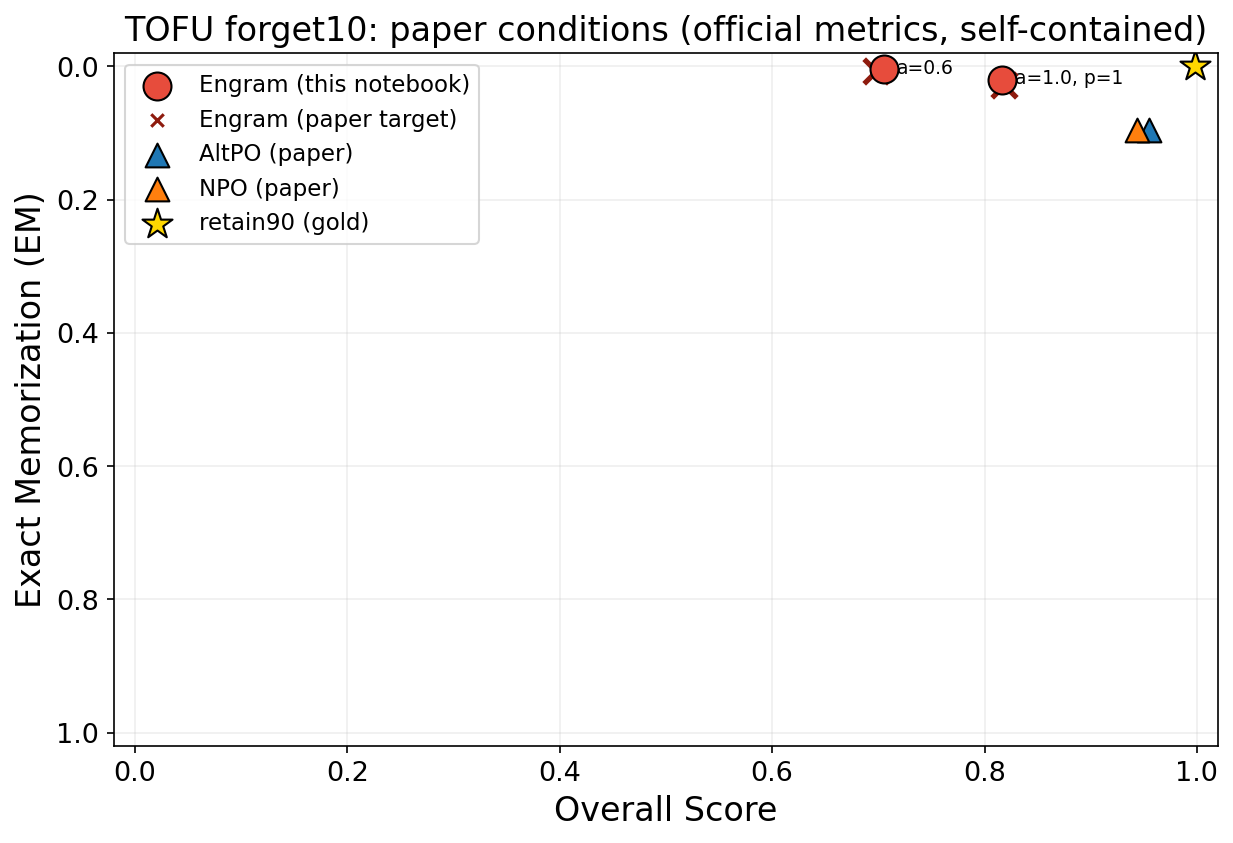

In [7]:
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 13, "axes.labelsize": 16, "axes.titlesize": 16, "figure.dpi": 150})
PAPER = {"plain a=0.6": (0.698, 0.007), "adaptive a=1.0,p=1": (0.818, 0.028)}   # (Overall, EM)
BASE  = {"AltPO": (0.955, 0.095), "NPO": (0.944, 0.095)}
fig, ax = plt.subplots(figsize=(9.5, 6))
eng = res[res.condition.str.startswith("Engram")]
ax.scatter(eng["Overall"], eng["EM"], s=180, color="#e74c3c", edgecolors="black", zorder=10, label="Engram (this notebook)")
for o, e in PAPER.values(): ax.scatter([o], [e], s=140, marker="x", color="#8e1b0e", linewidths=2.5, zorder=9)
ax.scatter([], [], marker="x", color="#8e1b0e", label="Engram (paper target)")
for m, (o, e) in BASE.items(): ax.scatter([o], [e], s=130, marker="^", edgecolors="black", label=f"{m} (paper)")
g = res[res.condition == "retain90 (gold)"]
ax.scatter(g["Overall"], g["EM"], s=230, marker="*", color="gold", edgecolors="black", zorder=5, label="retain90 (gold)")
for _, r in eng.iterrows():
    ax.annotate(r["condition"].split("(")[1].rstrip(")"), (r["Overall"], r["EM"]), fontsize=9, xytext=(6, -2), textcoords="offset points")
ax.set_xlabel("Overall Score"); ax.set_ylabel("Exact Memorization (EM)")
ax.set_title("TOFU forget10: paper conditions (official metrics, self-contained)")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.invert_yaxis(); ax.legend(fontsize=11); ax.grid(alpha=0.2)
fig.savefig("tofu_forget10_paper_conditions.png", bbox_inches="tight")
plt.show()